# YOLO-Seg Semantic Segmentation for Oak Defect Detection

**Goal**: Train an Ultralytics YOLO-Seg model as a **dense semantic segmentation** network for oak-plank defect detection (Background, BlackRot, Knot, Stain). Instead of using YOLO's native instance-segmentation pipeline (which outputs bounding boxes + polygon masks and requires NMS), we attach a **custom pixel-wise segmentation decoder** to a YOLO backbone so the model produces per-pixel class logits — exactly the format required by EBI's ONNX interpreter.

## Approach

1. **Backbone**: Use a frozen or fine-tuned YOLO backbone (e.g., YOLOv8n/s/m) as a feature extractor.
2. **Custom Segmentation Head**: Replace YOLO's detection/segmentation heads with a lightweight FPN-style decoder that outputs a `[B, C, H, W]` logit tensor (C = number of classes).
3. **Training**: Standard semantic-segmentation training with `CrossEntropyLoss`, the same dataset, augmentations, and splits used by the U-Net notebooks.
4. **Evaluation**: Confusion matrix, per-class IoU, F1, accuracy, and ROC curves — matching the U-Net evaluation protocol.
5. **ONNX Export**: EBI-compliant export via `EBIExportWrapper` (baked-in preprocessing → backbone+decoder → softmax → ×100 scaling).

## Key Libraries

| Library | Purpose |
|---|---|
| `ultralytics` | YOLO backbone (pretrained feature extractor) |
| `torch` / `torchvision` | Training loop, tensor operations |
| `albumentations` | Augmentations + normalization |
| `segmentation_models_pytorch` | *Not used here* — replaced by custom decoder |
| `scikit-learn` | Evaluation metrics |
| `matplotlib` | Visualization |
| `TensorBoard` | Training logging |

## 1. Imports and Configuration

In [1]:
import os
import json
import numpy as np
from pathlib import Path
from PIL import Image
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter

import albumentations as A
from albumentations.pytorch import ToTensorV2

from ultralytics import YOLO

import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, accuracy_score, f1_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

from functions.data_pipeline import prepare_dataset

# ──────────────────────────────────────────────
# Data preparation
# ──────────────────────────────────────────────
DATA_ROOT, class_mapping = prepare_dataset(
    mask_threshold=200,     # minimum masks to keep a defect class
    val_split=0.16,
    test_split=0.2,
)

# ──────────────────────────────────────────────
# Configuration — change these knobs as needed
# ──────────────────────────────────────────────
YOLO_BACKBONE   = "yolov8n-seg"   # Options: yolov8n-seg, yolov8s-seg, yolov8m-seg, etc.
FREEZE_BACKBONE = False           # If True, backbone weights are frozen during training
IMAGE_HEIGHT    = 384             # Resize height (Y)
IMAGE_WIDTH     = 1024            # Resize width (X)
BATCH_SIZE      = 16              # Adjust based on GPU memory
NUM_WORKERS     = 4
NUM_CLASSES     = len(class_mapping) + 1  # +1 for Background
LEARNING_RATE   = 1e-3
NUM_EPOCHS      = 50

# Class names aligned to class indices: 0=Background, 1..N from class_mapping
CLASS_NAMES = ["Background"] + [
    name for name, idx in sorted(class_mapping.items(), key=lambda x: x[1])
]
assert len(CLASS_NAMES) == NUM_CLASSES, (
    f"CLASS_NAMES ({len(CLASS_NAMES)}) != NUM_CLASSES ({NUM_CLASSES})"
)

# Keep these centralized for visualization/denormalization later
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Paths — project root auto-detection (works from notebooks/)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints" / "YOLO_SegHead"
MODELS_DIR     = PROJECT_ROOT / "models" / "YOLO_SegHead"
ONNX_DIR       = PROJECT_ROOT / "models" / "onnx"
LOG_DIR        = PROJECT_ROOT / "logs" / "tensorboard" / "YOLO_SegHead"

for d in [CHECKPOINT_DIR, MODELS_DIR, ONNX_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")
print(f"YOLO backbone: {YOLO_BACKBONE}")
print(f"Image size (HxW): {IMAGE_HEIGHT}x{IMAGE_WIDTH}")
print(f"Num classes: {NUM_CLASSES}")

PREPARE_DATASET — SKIPPED (data already prepared)
  Organized data: ../data/organized-data
  Classes: {'BlackRot': 1, 'Knot': 2, 'Stain': 3}
  (pass force=True to re-run the full pipeline)
Using device: cuda
YOLO backbone: yolov8n-seg
Image size (HxW): 384x1024
Num classes: 4


## 2. Dataset and Augmentations

Reuses the same organized-data layout and `split.json` as the U-Net notebooks.

In [2]:
class FullImageSegmentationDataset(Dataset):
    """Full-image semantic segmentation dataset (same as U-Net notebooks)."""

    def __init__(self, data_root, split="train", transform=None):
        self.data_root = Path(data_root)
        self.split = split
        self.transform = transform

        split_file = self.data_root / "split.json"
        with open(split_file, "r") as f:
            split_info = json.load(f)
        self.image_ids = split_info[split]

        self.images_dir = self.data_root / "images"
        self.masks_dir = self.data_root / "combined_masks"

        print(f"Loaded {split} dataset: {len(self.image_ids)} images (full image mode)")

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_path = self.images_dir / f"{img_id}_Col.tif"
        mask_path = self.masks_dir / f"{img_id}_mask.png"
        image = np.array(Image.open(img_path).convert("RGB"))
        mask = np.array(Image.open(mask_path))

        if self.transform:
            transformed = self.transform(image=image, mask=mask)
            image = transformed["image"]
            mask = transformed["mask"]

        return image, mask.long()


# ── Augmentations (same as U-Net notebooks) ──────────────────────────
def get_training_augmentation(image_height=IMAGE_HEIGHT, image_width=IMAGE_WIDTH):
    return A.Compose([
        A.Resize(image_height, image_width),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        #A.RandomRotate90(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5),
        A.OneOf([A.RandomBrightnessContrast(p=1), A.RandomGamma(p=1)], p=0.3),
        A.OneOf([A.GaussNoise(p=1), A.GaussianBlur(p=1)], p=0.2),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])


def get_validation_augmentation(image_height=IMAGE_HEIGHT, image_width=IMAGE_WIDTH):
    return A.Compose([
        A.Resize(image_height, image_width),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])


def create_dataloaders(
    data_root,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    image_height=IMAGE_HEIGHT,
    image_width=IMAGE_WIDTH,
):
    train_ds = FullImageSegmentationDataset(
        data_root, split="train", transform=get_training_augmentation(image_height, image_width)
    )
    val_ds = FullImageSegmentationDataset(
        data_root, split="val", transform=get_validation_augmentation(image_height, image_width)
    )
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=num_workers, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    return train_loader, val_loader


train_loader, val_loader = create_dataloaders(DATA_ROOT)

Loaded train dataset: 688 images (full image mode)
Loaded val dataset: 132 images (full image mode)


/home/vscode/.local/lib/python3.10/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## 3. Model — YOLO Backbone + Custom Semantic-Segmentation Decoder

The YOLO backbone produces multi-scale feature maps. We extract features at three
scales from the backbone and neck (P3, P4, P5) and feed them into a lightweight
FPN-style decoder that upsamples and fuses them into a dense per-pixel logit map.

In [3]:
class YOLOBackbone(nn.Module):
    """
    Wraps an Ultralytics YOLO-Seg model and exposes its backbone+neck
    feature maps at three scales (P3, P4, P5).
    """

    def __init__(self, yolo_variant: str = "yolov8n-seg", freeze: bool = False):
        super().__init__()
        # Load the pretrained YOLO-Seg model
        yolo_model = YOLO(yolo_variant)
        self.backbone = yolo_model.model.model  # nn.Sequential of YOLO layers

        # Identify the feature-output layer indices by probing with a dummy input.
        # We'll capture outputs from the layers that correspond to P3, P4, P5.
        self._feature_indices = self._find_feature_indices()

        if freeze:
            for param in self.backbone.parameters():
                param.requires_grad = False

    def _find_feature_indices(self):
        """
        Run a dummy forward pass to identify which layers output P3, P4, P5.
        For YOLOv8, the typical multi-scale feature indices are the last three
        feature maps produced by the backbone/neck before the detection heads.
        """
        dummy = torch.randn(1, 3, 256, 256)
        outputs = []
        x = dummy
        for i, layer in enumerate(self.backbone):
            # Some layers need the list of previous saved features
            if hasattr(layer, "f") and layer.f != -1:
                # layer.f can be an int or a list of ints referencing earlier layers
                if isinstance(layer.f, int):
                    x = outputs[layer.f]
                elif isinstance(layer.f, (list, tuple)):
                    x = [outputs[j] for j in layer.f]
            x = layer(x)
            outputs.append(x)

        # Find the three largest spatial feature maps (excluding the input-sized ones)
        # that are tensors (not lists). These are our P3, P4, P5 candidates.
        tensor_outputs = [(i, o) for i, o in enumerate(outputs) if isinstance(o, torch.Tensor) and o.dim() == 4]

        # Group by spatial resolution
        resolution_groups = {}
        for idx, t in tensor_outputs:
            h, w = t.shape[2], t.shape[3]
            key = (h, w)
            if key not in resolution_groups:
                resolution_groups[key] = []
            resolution_groups[key].append((idx, t))

        # Sort resolutions from largest to smallest
        sorted_resolutions = sorted(resolution_groups.keys(), key=lambda x: x[0] * x[1], reverse=True)

        # Pick the top 3 resolutions (P3=largest, P4=mid, P5=smallest among top 3)
        # We want the LAST layer index at each resolution
        feature_indices = []
        for res in sorted_resolutions[:3]:
            layers_at_res = resolution_groups[res]
            # Pick the last one at this resolution
            feature_indices.append(layers_at_res[-1][0])

        # Sort indices so P3 (largest spatial) is first
        feature_indices.sort(key=lambda idx: outputs[idx].shape[2] * outputs[idx].shape[3], reverse=True)

        # Get channel counts
        channels = [outputs[idx].shape[1] for idx in feature_indices]
        self._feature_channels = channels
        print(f"YOLO backbone feature indices: {feature_indices}")
        print(f"Feature map channels: {channels}")
        print(f"Feature map sizes at 256x256 input: {[outputs[idx].shape[2:] for idx in feature_indices]}")

        return feature_indices

    @property
    def feature_channels(self):
        return self._feature_channels

    def forward(self, x):
        """Returns a list of feature maps [P3, P4, P5] (largest to smallest)."""
        outputs = []
        for i, layer in enumerate(self.backbone):
            if hasattr(layer, "f") and layer.f != -1:
                if isinstance(layer.f, int):
                    x = outputs[layer.f]
                elif isinstance(layer.f, (list, tuple)):
                    x = [outputs[j] for j in layer.f]
            x = layer(x)
            outputs.append(x)

        features = [outputs[idx] for idx in self._feature_indices]
        return features


class SegmentationDecoder(nn.Module):
    """
    Lightweight FPN-style decoder for dense semantic segmentation.
    Takes multi-scale features (P3, P4, P5) and produces a per-pixel logit map.
    """

    def __init__(self, feature_channels, num_classes=4, decoder_channels=128):
        super().__init__()
        # Lateral 1×1 convolutions to unify channel dimensions
        self.lateral_convs = nn.ModuleList([
            nn.Conv2d(ch, decoder_channels, 1) for ch in feature_channels
        ])

        # Smoothing 3×3 convolutions after FPN fusion
        self.smooth_convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(decoder_channels, decoder_channels, 3, padding=1),
                nn.BatchNorm2d(decoder_channels),
                nn.ReLU(inplace=True),
            ) for _ in feature_channels
        ])

        # Final segmentation head
        self.seg_head = nn.Sequential(
            nn.Conv2d(decoder_channels, decoder_channels, 3, padding=1),
            nn.BatchNorm2d(decoder_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(decoder_channels, num_classes, 1),
        )

    def forward(self, features, target_size):
        """
        Args:
            features: list of [P3, P4, P5] tensors (largest spatial first)
            target_size: (H, W) of the desired output
        Returns:
            logits: [B, num_classes, H, W]
        """
        # Apply lateral convolutions
        laterals = [conv(f) for conv, f in zip(self.lateral_convs, features)]

        # Top-down FPN fusion: start from smallest (last) and upsample to larger
        for i in range(len(laterals) - 1, 0, -1):
            h, w = laterals[i - 1].shape[2:]
            laterals[i - 1] = laterals[i - 1] + F.interpolate(
                laterals[i], size=(h, w), mode="bilinear", align_corners=False
            )

        # Apply smoothing
        for i in range(len(laterals)):
            laterals[i] = self.smooth_convs[i](laterals[i])

        # Use the highest-resolution fused feature (P3 level)
        x = laterals[0]

        # Upsample to target size
        x = F.interpolate(x, size=target_size, mode="bilinear", align_corners=False)

        # Segmentation head
        logits = self.seg_head(x)
        return logits


class YOLOSegModel(nn.Module):
    """
    Full model: YOLO backbone + FPN segmentation decoder.
    Input:  [B, 3, H, W] (ImageNet-normalized float32)
    Output: [B, num_classes, H, W] logits
    """

    def __init__(self, yolo_variant="yolov8n-seg", num_classes=4,
                 decoder_channels=128, freeze_backbone=False):
        super().__init__()
        self.backbone = YOLOBackbone(yolo_variant, freeze=freeze_backbone)
        self.decoder = SegmentationDecoder(
            feature_channels=self.backbone.feature_channels,
            num_classes=num_classes,
            decoder_channels=decoder_channels,
        )

    def forward(self, x):
        target_size = (x.shape[2], x.shape[3])
        features = self.backbone(x)
        logits = self.decoder(features, target_size)
        return logits


# ── Build model ──────────────────────────────────────────
model = YOLOSegModel(
    yolo_variant=YOLO_BACKBONE,
    num_classes=NUM_CLASSES,
    decoder_channels=128,
    freeze_backbone=FREEZE_BACKBONE,
).to(DEVICE)

# Quick sanity check
with torch.no_grad():
    dummy = torch.randn(1, 3, IMAGE_HEIGHT, IMAGE_WIDTH, device=DEVICE)
    out = model(dummy)
    print(f"Model output shape: {out.shape}")
    assert out.shape == (1, NUM_CLASSES, IMAGE_HEIGHT, IMAGE_WIDTH), f"Unexpected shape: {out.shape}"
    print("✓ Model sanity check passed")

YOLO backbone feature indices: [0, 2, 15]
Feature map channels: [16, 32, 64]
Feature map sizes at 256x256 input: [torch.Size([128, 128]), torch.Size([64, 64]), torch.Size([32, 32])]
Model output shape: torch.Size([1, 4, 384, 1024])
✓ Model sanity check passed


## 4. Training Utilities — Loss, Metrics, and Training Loop

In [4]:
def compute_iou(preds, targets, num_classes):
    """Compute per-class IoU and mean IoU."""
    ious = []
    for cls in range(num_classes):
        pred_mask = (preds == cls)
        target_mask = (targets == cls)
        intersection = (pred_mask & target_mask).sum().item()
        union = (pred_mask | target_mask).sum().item()
        if union == 0:
            ious.append(float('nan'))
        else:
            ious.append(intersection / union)
    return ious


def train_one_epoch(model, dataloader, criterion, optimizer, device, num_classes):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_targets = []

    for images, masks in dataloader:
        images = images.to(device)
        masks = masks.to(device).long()

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.append(preds)
        all_targets.append(masks.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    all_preds = np.concatenate(all_preds).flatten()
    all_targets = np.concatenate(all_targets).flatten()
    ious = compute_iou(
        torch.tensor(all_preds), torch.tensor(all_targets), num_classes
    )
    mean_iou = np.nanmean(ious)
    return epoch_loss, mean_iou, ious


@torch.no_grad()
def validate(model, dataloader, criterion, device, num_classes):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_targets = []

    for images, masks in dataloader:
        images = images.to(device)
        masks = masks.to(device).long()

        logits = model(images)
        loss = criterion(logits, masks)

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.append(preds)
        all_targets.append(masks.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    all_preds = np.concatenate(all_preds).flatten()
    all_targets = np.concatenate(all_targets).flatten()
    ious = compute_iou(
        torch.tensor(all_preds), torch.tensor(all_targets), num_classes
    )
    mean_iou = np.nanmean(ious)
    return epoch_loss, mean_iou, ious


print("✓ Training utilities defined")

✓ Training utilities defined


## 5. Training Loop with Checkpoint Saving

In [ ]:
# ── Loss, optimizer, scheduler ─────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=1e-4,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5
)

# ── Checkpoint directory ───────────────────────────────
checkpoint_dir = Path(PROJECT_ROOT) / "checkpoints"
checkpoint_dir.mkdir(parents=True, exist_ok=True)
best_model_path = checkpoint_dir / "yolo_seg_best.pth"

# ── TensorBoard ───────────────────────────────────────
log_dir = LOG_DIR
writer = SummaryWriter(log_dir=str(log_dir))

# ── Training loop ─────────────────────────────────────
best_val_iou = 0.0
history = {"train_loss": [], "val_loss": [], "train_iou": [], "val_iou": []}

for epoch in range(NUM_EPOCHS):
    train_loss, train_iou, train_class_ious = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE, NUM_CLASSES
    )
    val_loss, val_iou, val_class_ious = validate(
        model, val_loader, criterion, DEVICE, NUM_CLASSES
    )
    scheduler.step(val_loss)

    # Logging
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_iou"].append(train_iou)
    history["val_iou"].append(val_iou)

    writer.add_scalar("Loss/train", train_loss, epoch)
    writer.add_scalar("Loss/val", val_loss, epoch)
    writer.add_scalar("mIoU/train", train_iou, epoch)
    writer.add_scalar("mIoU/val", val_iou, epoch)
    writer.add_scalar("LR", optimizer.param_groups[0]["lr"], epoch)

    # Print progress
    class_iou_str = " | ".join(
        f"{CLASS_NAMES[i]}: {val_class_ious[i]:.4f}" if not np.isnan(val_class_ious[i]) else f"{CLASS_NAMES[i]}: N/A"
        for i in range(NUM_CLASSES)
    )
    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
        f"Train mIoU: {train_iou:.4f} | Val mIoU: {val_iou:.4f}"
    )
    print(f"  Per-class val IoU: {class_iou_str}")

    # Save best model
    if val_iou > best_val_iou:
        best_val_iou = val_iou
        torch.save(model.state_dict(), best_model_path)
        print(f"  ✓ Best model saved (mIoU={val_iou:.4f})")

writer.close()
print(f"\nTraining complete. Best validation mIoU: {best_val_iou:.4f}")

## 6. Training Curves

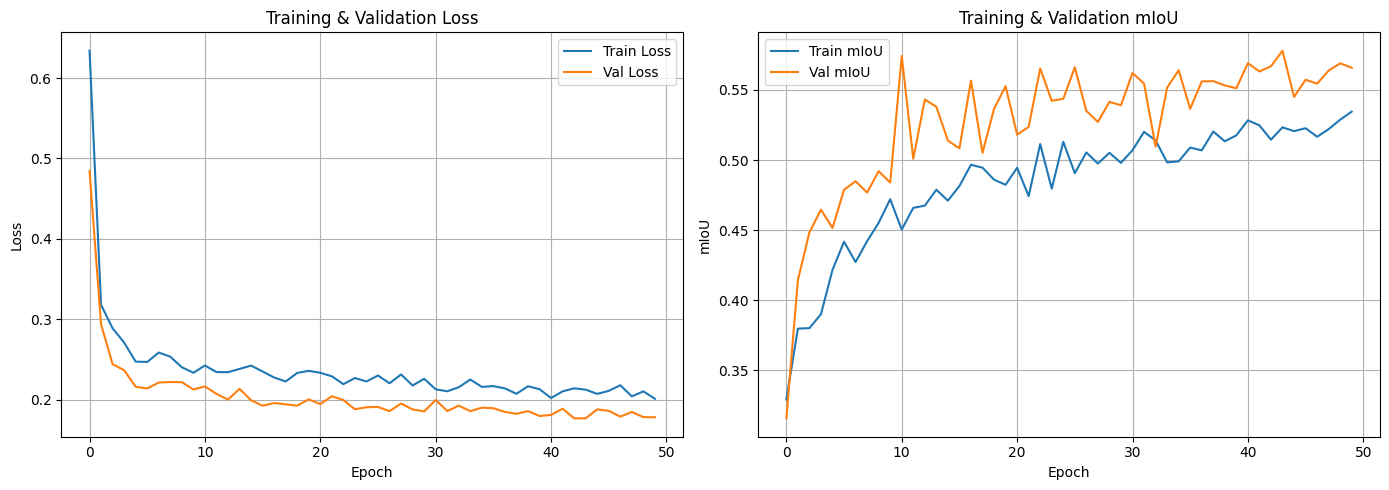

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"], label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training & Validation Loss")
axes[0].legend()
axes[0].grid(True)

# mIoU curves
axes[1].plot(history["train_iou"], label="Train mIoU")
axes[1].plot(history["val_iou"], label="Val mIoU")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("mIoU")
axes[1].set_title("Training & Validation mIoU")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 7. Evaluation on Test Set — Confusion Matrix, ROC Curves, and Visual Predictions

Loaded test dataset: 111 images (full image mode)


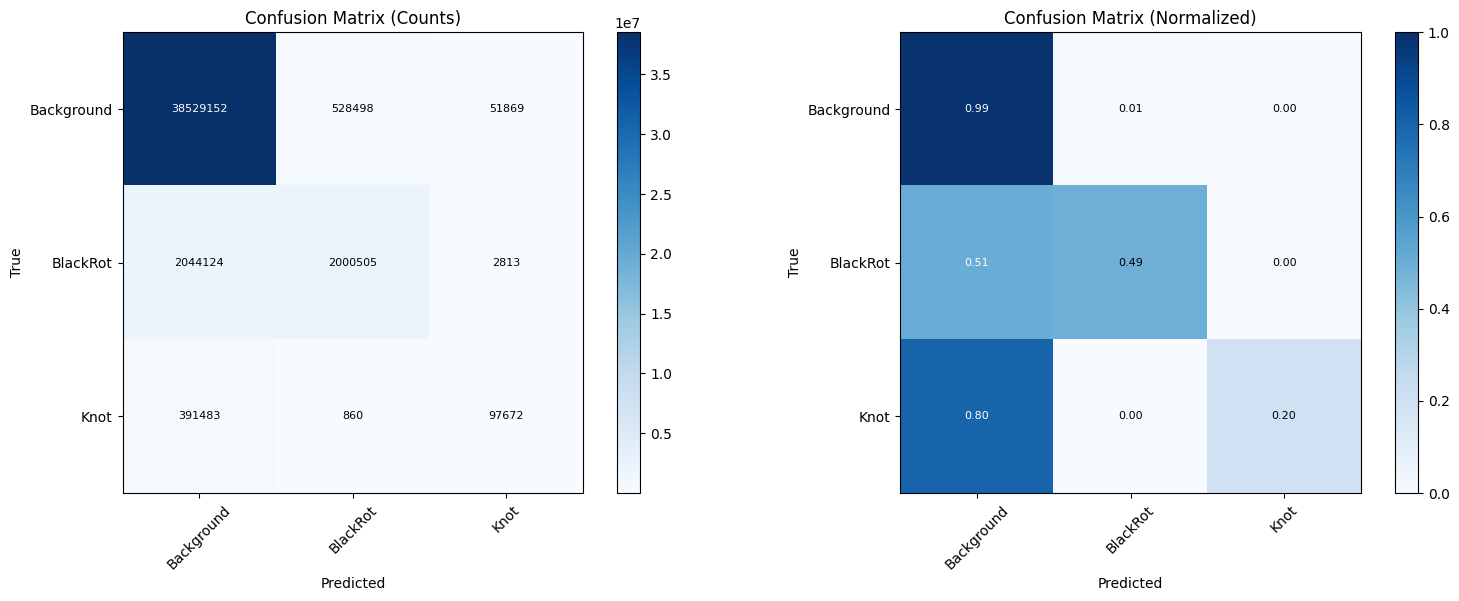


Test Accuracy:  0.9308
Test F1 (macro): 0.6249
Test mIoU:       0.5146

Class              F1      IoU
------------------------------
Background     0.9623   0.9274
BlackRot       0.6083   0.4371
Knot           0.3041   0.1793


In [ ]:
# Build test dataset/loader for evaluation cells
test_dataset = FullImageSegmentationDataset(
    DATA_ROOT,
    split="test",
    transform=get_validation_augmentation(IMAGE_HEIGHT, IMAGE_WIDTH),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

# Load best model weights
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()

# ── Collect predictions on test set ───────────────────
all_preds = []
all_targets = []
all_probs = []

with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(DEVICE)
        logits = model(images)
        probs = F.softmax(logits, dim=1)

        all_probs.append(probs.cpu().numpy())
        all_preds.append(logits.argmax(dim=1).cpu().numpy())
        all_targets.append(masks.numpy())

all_preds = np.concatenate(all_preds).flatten()
all_targets = np.concatenate(all_targets).flatten()
all_probs = np.concatenate(all_probs)  # [N, C, H, W]

# ── Confusion Matrix ──────────────────────────────────
cm = confusion_matrix(all_targets, all_preds, labels=list(range(NUM_CLASSES)))
cm_normalized = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
im0 = axes[0].imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
axes[0].set_title("Confusion Matrix (Counts)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].set_xticks(range(NUM_CLASSES))
axes[0].set_yticks(range(NUM_CLASSES))
axes[0].set_xticklabels(CLASS_NAMES, rotation=45)
axes[0].set_yticklabels(CLASS_NAMES)
plt.colorbar(im0, ax=axes[0])
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        axes[0].text(j, i, f"{cm[i, j]}", ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=8)

# Normalized
im1 = axes[1].imshow(cm_normalized, interpolation="nearest", cmap=plt.cm.Blues, vmin=0, vmax=1)
axes[1].set_title("Confusion Matrix (Normalized)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
axes[1].set_xticks(range(NUM_CLASSES))
axes[1].set_yticks(range(NUM_CLASSES))
axes[1].set_xticklabels(CLASS_NAMES, rotation=45)
axes[1].set_yticklabels(CLASS_NAMES)
plt.colorbar(im1, ax=axes[1])
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        axes[1].text(j, i, f"{cm_normalized[i, j]:.2f}", ha="center", va="center",
                     color="white" if cm_normalized[i, j] > 0.5 else "black", fontsize=8)

plt.tight_layout()
plt.show()

# ── Per-class metrics ─────────────────────────────────
acc = accuracy_score(all_targets, all_preds)
f1_macro = f1_score(all_targets, all_preds, average="macro", zero_division=0)
f1_per_class = f1_score(all_targets, all_preds, average=None, zero_division=0, labels=list(range(NUM_CLASSES)))
test_ious = compute_iou(torch.tensor(all_preds), torch.tensor(all_targets), NUM_CLASSES)

print(f"\nTest Accuracy:  {acc:.4f}")
print(f"Test F1 (macro): {f1_macro:.4f}")
print(f"Test mIoU:       {np.nanmean(test_ious):.4f}")
print(f"\n{'Class':<12} {'F1':>8} {'IoU':>8}")
print("-" * 30)
for i in range(NUM_CLASSES):
    iou_str = f"{test_ious[i]:.4f}" if not np.isnan(test_ious[i]) else "N/A"
    print(f"{CLASS_NAMES[i]:<12} {f1_per_class[i]:>8.4f} {iou_str:>8}")

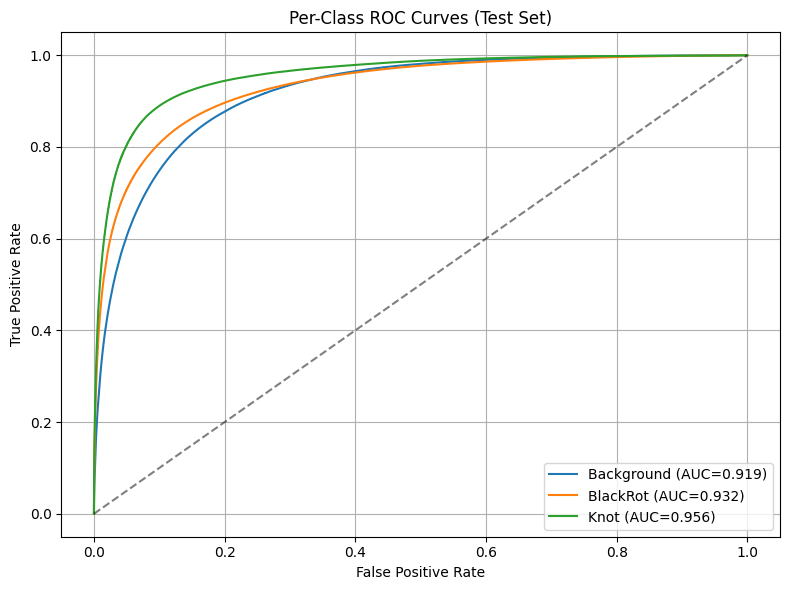

In [ ]:
# ── ROC Curves (one-vs-rest per class) ─────────────────
# Reshape probabilities: [N_images, C, H, W] → [N_pixels, C]
n_images = all_probs.shape[0]
probs_flat = all_probs.transpose(0, 2, 3, 1).reshape(-1, NUM_CLASSES)  # [N_pixels, C]
targets_bin = label_binarize(all_targets, classes=list(range(NUM_CLASSES)))

fig, ax = plt.subplots(figsize=(8, 6))
for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(targets_bin[:, i], probs_flat[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{CLASS_NAMES[i]} (AUC={roc_auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Per-Class ROC Curves (Test Set)")
ax.legend(loc="lower right")
ax.grid(True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_6476/3206890289.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  CMAP = plt.cm.get_cmap("tab10", NUM_CLASSES)


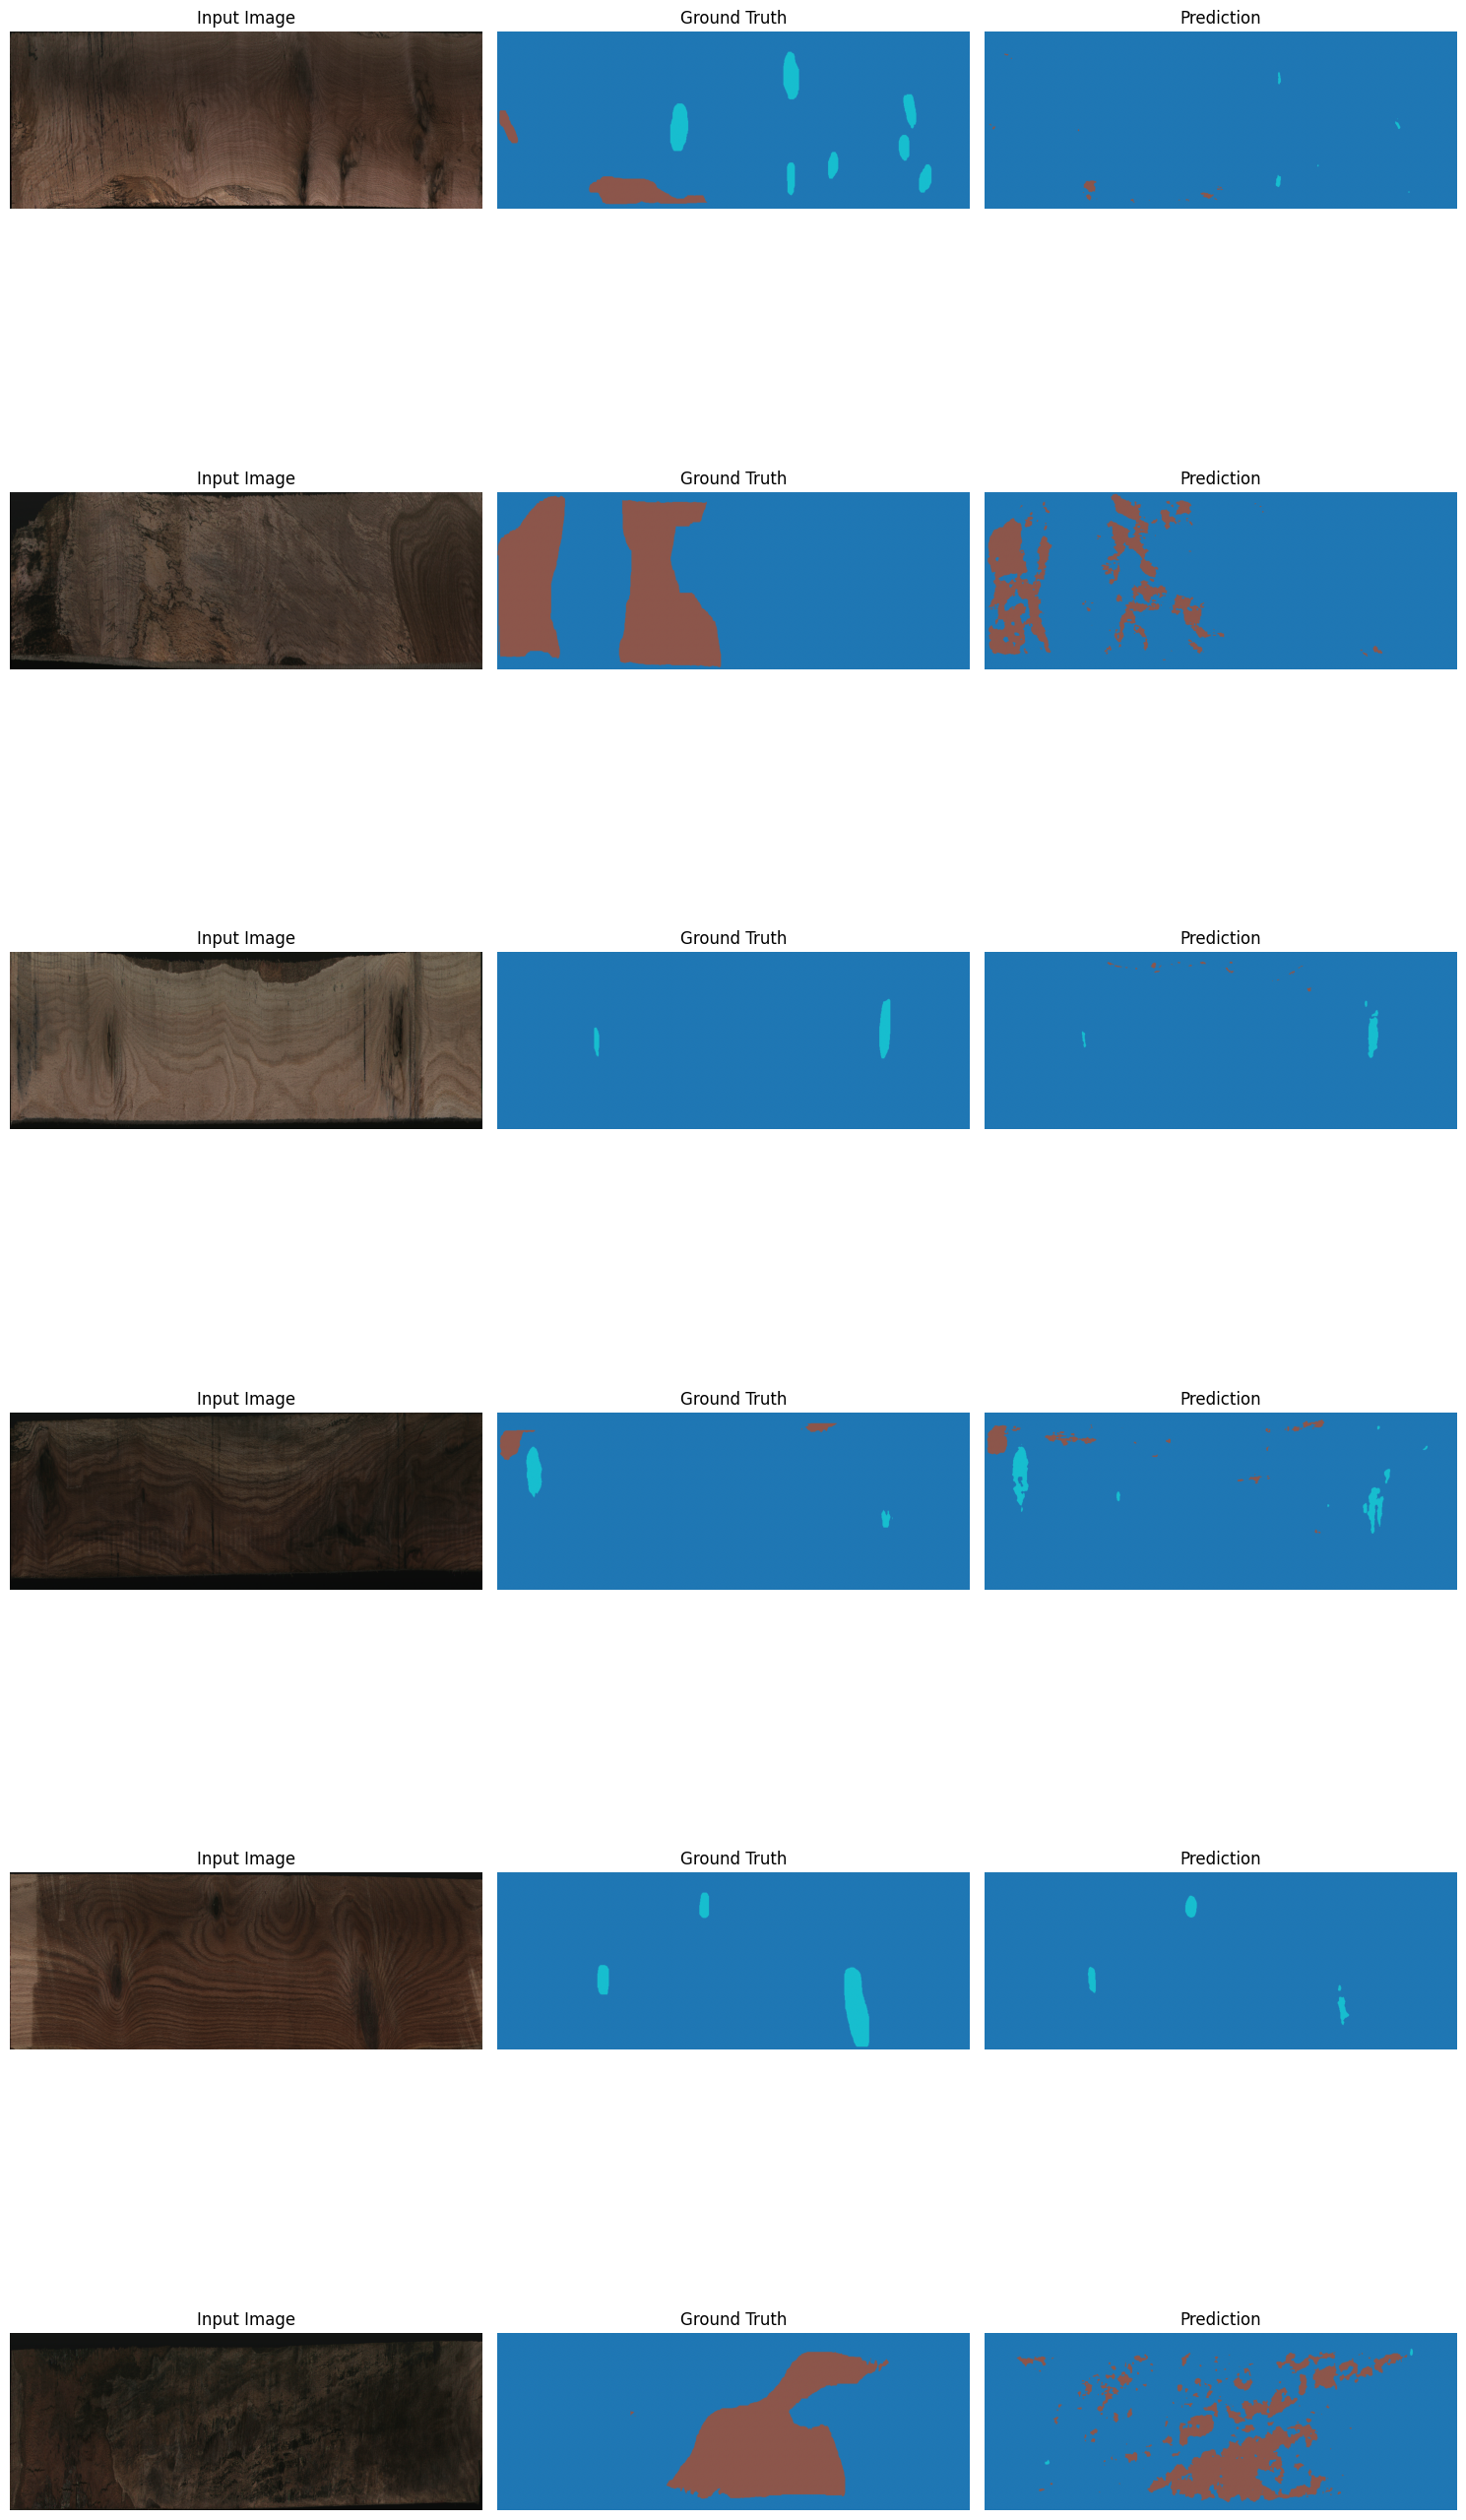

In [ ]:
# ── Visual Predictions (sample test images) ────────────
CMAP = plt.cm.get_cmap("tab10", NUM_CLASSES)

num_samples = min(6, len(test_dataset))
fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))
if num_samples == 1:
    axes = axes[np.newaxis, :]

for i in range(num_samples):
    image, mask = test_dataset[i]
    with torch.no_grad():
        logits = model(image.unsqueeze(0).to(DEVICE))
        pred = logits.argmax(dim=1).squeeze(0).cpu().numpy()

    # Denormalize image for display
    img_np = image.permute(1, 2, 0).cpu().numpy()
    img_np = img_np * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    img_np = np.clip(img_np, 0, 1)

    axes[i, 0].imshow(img_np)
    axes[i, 0].set_title("Input Image")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask.numpy(), cmap=CMAP, vmin=0, vmax=NUM_CLASSES - 1)
    axes[i, 1].set_title("Ground Truth")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(pred, cmap=CMAP, vmin=0, vmax=NUM_CLASSES - 1)
    axes[i, 2].set_title("Prediction")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

## 8. ONNX Export — EBI-Compliant Format

The exported ONNX model embeds **all preprocessing and postprocessing** directly in the graph:

1. **Input**: `uint8 [B, 3, H, W]` raw RGB image
2. **Preprocessing** (baked in): `float32` conversion, `/255.0`, ImageNet mean/std normalization
3. **Backbone + Decoder**: produces per-pixel class logits `[B, C, H, W]`
4. **Postprocessing** (baked in): softmax → scale by 100.0 → `float32 [B, C, H, W]` percentage scores

EBI's ONNX interpreter receives dense 0-100% per-pixel class scores with no NMS, no bounding boxes, and no decoder-side post-processing.

In [ ]:
import torch.onnx


class EBIExportWrapper(nn.Module):
    """
    Wraps a trained segmentation model for EBI-compliant ONNX export.

    The ONNX graph will contain:
      Input:  uint8  [B, 3, H, W]  (raw RGB image, 0-255)
      Output: float32 [B, C, H, W] (per-pixel class scores, 0-100%)

    Baked-in operations:
      1. Cast uint8 → float32, divide by 255.0
      2. ImageNet mean/std normalization
      3. Forward through the segmentation backbone+decoder (logits)
      4. Softmax over the class dimension
      5. Multiply by 100.0 (percentage scale)
    """

    def __init__(self, seg_model, mean=None, std=None):
        super().__init__()
        self.seg_model = seg_model
        # Register mean/std as buffers so they are part of the ONNX graph
        if mean is None:
            mean = [0.485, 0.456, 0.406]
        if std is None:
            std = [0.229, 0.224, 0.225]
        self.register_buffer("mean", torch.tensor(mean, dtype=torch.float32).view(1, 3, 1, 1))
        self.register_buffer("std", torch.tensor(std, dtype=torch.float32).view(1, 3, 1, 1))

    def forward(self, x):
        # x: uint8 [B, 3, H, W] → float32 [B, 3, H, W] in [0, 1]
        x = x.float() / 255.0
        # ImageNet normalization
        x = (x - self.mean) / self.std
        # Segmentation model forward
        logits = self.seg_model(x)
        # Softmax over class dimension → probabilities [0, 1]
        probs = F.softmax(logits, dim=1)
        # Scale to 0-100%
        scores = probs * 100.0
        return scores


# ── Build the EBI wrapper ─────────────────────────────
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()

ebi_model = EBIExportWrapper(model).to(DEVICE)
ebi_model.eval()

# ── ONNX export ───────────────────────────────────────
onnx_dir = PROJECT_ROOT / "models" / "onnx"
onnx_dir.mkdir(parents=True, exist_ok=True)
onnx_path = onnx_dir / "yolo_seg.onnx"

# Dummy input: uint8 image (as the ONNX graph expects raw images)
dummy_input = torch.randint(
    0, 256, (1, 3, IMAGE_HEIGHT, IMAGE_WIDTH), dtype=torch.uint8, device=DEVICE
)

torch.onnx.export(
    ebi_model,
    dummy_input,
    onnx_path.as_posix(),
    input_names=["input"],
    output_names=["output"],
    opset_version=12,
    dynamo=False,
    dynamic_axes={
        "input":  {0: "batch", 2: "height", 3: "width"},
        "output": {0: "batch", 2: "height", 3: "width"},
    },
)

print(f"✓ Exported EBI-compliant ONNX model to: {onnx_path}")
print(f"  Input:  uint8  [B, 3, H, W]  (raw RGB 0-255)")
print(f"  Output: float32 [B, {NUM_CLASSES}, H, W] (per-pixel class scores 0-100%)")

/tmp/ipykernel_6476/3161199739.py:62: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0313 11:25:55.269000 6476 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0313 11:26:01.565000 6476 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, a

[torch.onnx] Obtain model graph for `EBIExportWrapper([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `EBIExportWrapper([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.10/copyreg.py:101: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


Failed to convert the model to the target version 17 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/home/vscode/.local/lib/python3.10/site-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
  File "/home/vscode/.local/lib/python3.10/site-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
  File "/home/vscode/.local/lib/python3.10/site-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
  File "/home/vscode/.local/lib/python3.10/site-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
RuntimeError: /github/workspace/onnx/version_converter/BaseConverter.h:65: adapter_lookup: Assertion `false` failed: No Adapter To Version $17 for Resize


Applied 74 of general pattern rewrite rules.
✓ Exported EBI-compliant ONNX model to: /workspaces/Oak-Defect-Detection/models/onnx/yolo_seg.onnx
  Input:  uint8  [B, 3, H, W]  (raw RGB 0-255)
  Output: float32 [B, 3, H, W] (per-pixel class scores 0-100%)


In [ ]:
# ── Verify ONNX model ─────────────────────────────────
import onnxruntime as ort

session = ort.InferenceSession(onnx_path.as_posix())
inp_meta = session.get_inputs()[0]
out_meta = session.get_outputs()[0]

print(f"ONNX Input:  name={inp_meta.name}, shape={inp_meta.shape}, type={inp_meta.type}")
print(f"ONNX Output: name={out_meta.name}, shape={out_meta.shape}, type={out_meta.type}")

# Run a quick inference with a random uint8 image
test_input = np.random.randint(0, 256, (1, 3, IMAGE_HEIGHT, IMAGE_WIDTH)).astype(np.uint8)
onnx_output = session.run(None, {inp_meta.name: test_input})[0]

print(f"\nTest inference:")
print(f"  Input shape:  {test_input.shape}, dtype: {test_input.dtype}")
print(f"  Output shape: {onnx_output.shape}, dtype: {onnx_output.dtype}")
print(f"  Output range: [{onnx_output.min():.2f}, {onnx_output.max():.2f}]")
print(f"  Sum along class axis (should be ~100 everywhere): "
      f"min={onnx_output.sum(axis=1).min():.2f}, max={onnx_output.sum(axis=1).max():.2f}")

assert onnx_output.dtype == np.float32, f"Expected float32, got {onnx_output.dtype}"
assert onnx_output.shape[1] == NUM_CLASSES, f"Expected {NUM_CLASSES} classes, got {onnx_output.shape[1]}"
class_sums = onnx_output.sum(axis=1)
assert np.allclose(class_sums, 100.0, atol=0.1), f"Class scores don't sum to 100%"
print("\n✓ ONNX model verification passed — EBI-compliant format confirmed")

ONNX Input:  name=image, shape=['batch', 3, 'height', 'width'], type=tensor(uint8)
ONNX Output: name=scores, shape=[1, 3, 'height', 'width'], type=tensor(float)

Test inference:
  Input shape:  (1, 3, 384, 1024), dtype: uint8
  Output shape: (1, 3, 384, 1024), dtype: float32
  Output range: [0.01, 99.90]
  Sum along class axis (should be ~100 everywhere): min=100.00, max=100.00

✓ ONNX model verification passed — EBI-compliant format confirmed
